In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('DataBikes_new.csv')
df

,Unnamed: 0,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Rental count,score,score_type,Temperature Category
0,0,01/12/2017,0,-5.2,37,2.2,0.0,0.0,Winter,No Holiday,Yes,257,56.0,0-100,frost
1,1,01/12/2017,1,-5.5,38,0.8,0.0,0.0,Winter,No Holiday,Yes,219,3.0,0-10,frost
2,2,01/12/2017,2,-6.0,39,1.0,0.0,0.0,Winter,No Holiday,Yes,162,7.0,0-10,frost
3,3,01/12/2017,3,-6.2,40,0.9,0.0,0.0,Winter,No Holiday,Yes,148,8.0,0-10,frost
4,4,01/12/2017,4,-6.0,36,2.3,0.0,0.0,Winter,No Holiday,Yes,97,10.0,0-100,frost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,8755,30/11/2018,19,4.2,34,2.6,0.0,0.0,Autumn,No Holiday,Yes,644,55.0,0-100,cold
8756,8756,30/11/2018,20,3.4,37,2.3,0.0,0.0,Autumn,No Holiday,Yes,359,10.0,0-100,cold
8757,8757,30/11/2018,21,2.6,39,0.3,0.0,0.0,Autumn,No Holiday,Yes,1236,8.0,0-10,cold
8758,8758,30/11/2018,22,2.1,41,1.0,0.0,0.0,Autumn,No Holiday,Yes,628,8.0,0-10,cold


1. Проанализируйте переменные (столбцы) и укажите, для каких из них определение
числовых характеристик имеет смысл. Понимать значения всех характеристик, которые
дает метод describe().

In [3]:
df.dtypes

Unnamed: 0                int64
Date                     object
Hour                      int64
Temperature             float64
Humidity                  int64
Wind speed              float64
Rainfall                float64
Snowfall                float64
Seasons                  object
Holiday                  object
Functioning Day          object
Rental count              int64
score                   float64
score_type               object
Temperature Category     object
dtype: object

Куда имеет смысл считать числовые характеристики (mean, std, min, quartiles, max)
- Hour
- Temperature
- Humidity
- Wind speed
- Rainfall
- Snowfall
- Rental count
- score

Где не имеет смысла как для чисел
- Unnamed: 0 — это индекс/идентификатор
- Все object: Date, Seasons, Holiday, Functioning Day, score_type, Temperature Category

In [4]:
df.describe()

,Unnamed: 0,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Rental count,score
count,8760.000000,8760.000000,8581.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,4379.500000,11.500000,12.878557,58.226256,1.724909,0.148687,0.075068,696.582078,31.619406
std,2528.938512,6.922582,11.955551,20.362413,1.036300,1.128193,0.436746,749.812613,31.716206
min,0.000000,0.000000,-17.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2189.750000,5.750000,3.400000,42.000000,0.900000,0.000000,0.000000,157.000000,8.000000
50%,4379.500000,11.500000,13.700000,57.000000,1.500000,0.000000,0.000000,425.500000,10.000000
75%,6569.250000,17.250000,22.500000,74.000000,2.300000,0.000000,0.000000,1009.000000,61.000000
max,8759.000000,23.000000,39.400000,98.000000,7.400000,35.000000,8.800000,6012.000000,100.000000


In [5]:
df.describe(include='all')

,Unnamed: 0,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Rental count,score,score_type,Temperature Category
count,8760.000000,8760,8760.000000,8581.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760,8760.000000,8760.000000,8760,8581
unique,NaN,365,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,2,5
top,NaN,01/12/2017,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes,NaN,NaN,0-100,warm
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465,NaN,NaN,5760,2555
mean,4379.500000,NaN,11.500000,12.878557,58.226256,1.724909,0.148687,0.075068,NaN,NaN,NaN,696.582078,31.619406,NaN,NaN
std,2528.938512,NaN,6.922582,11.955551,20.362413,1.036300,1.128193,0.436746,NaN,NaN,NaN,749.812613,31.716206,NaN,NaN
min,0.000000,NaN,0.000000,-17.800000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
25%,2189.750000,NaN,5.750000,3.400000,42.000000,0.900000,0.000000,0.000000,NaN,NaN,NaN,157.000000,8.000000,NaN,NaN
50%,4379.500000,NaN,11.500000,13.700000,57.000000,1.500000,0.000000,0.000000,NaN,NaN,NaN,425.500000,10.000000,NaN,NaN
75%,6569.250000,NaN,17.250000,22.500000,74.000000,2.300000,0.000000,0.000000,NaN,NaN,NaN,1009.000000,61.000000,NaN,NaN


для числовых
- count: число ненулевых наблюдений (без NaN).
- mean: среднее значение.
- std: стандартное отклонение (разброс значений).
- min: минимальное значение.
- 25% (Q1): первый квартиль — 25% наблюдений меньше этого значения.
- 50% (median): медиана — середина распределения.
- 75% (Q3): третий квартиль — 75% наблюдений меньше этого значения.
- max: максимальное значение.

не числовых
- count: число значений,
- unique: число уникальных категорий,
- top: самая частая категория,
- freq: её частота.

2. Для каждого сезона найдите: среднюю, медианную и модовую температуры,
дисперсию, среднеквадратичное отклонение, размах и интерквартильный размах
температуры. Результат также выведите в виде общей таблицы.

In [6]:
#осень
autumn_temp = df[df['Seasons'] == 'Autumn']['Temperature']

autumn_mean = autumn_temp.mean()

autumn_median = autumn_temp.median()

autumn_mode = autumn_temp.mode().iloc[0]

autumn_var = autumn_temp.var()

autumn_std = autumn_temp.std()

autumn_range = autumn_temp.max() - autumn_temp.min()

autumn_iqr = autumn_temp.quantile(0.75) - autumn_temp.quantile(0.25)

#весна
spring_temp = df[df['Seasons'] == 'Spring']['Temperature']

spring_mean = spring_temp.mean()

spring_median = spring_temp.median()

spring_mode = spring_temp.mode().iloc[0]

spring_var = spring_temp.var()

spring_std = spring_temp.std()

spring_range = spring_temp.max() - spring_temp.min()

spring_iqr = spring_temp.quantile(0.75) - spring_temp.quantile(0.25)

#зима
winter_temp = df[df['Seasons'] == 'Winter']['Temperature']

winter_mean = winter_temp.mean()

winter_median = winter_temp.median()

winter_mode = winter_temp.mode().iloc[0]

winter_var = winter_temp.var()

winter_std = winter_temp.std()

winter_range = winter_temp.max() - winter_temp.min()

winter_iqr = winter_temp.quantile(0.75) - winter_temp.quantile(0.25)

#лето
summer_temp = df[df['Seasons'] == 'Summer']['Temperature']

summer_mean = summer_temp.mean()

summer_median = summer_temp.median()

summer_mode = summer_temp.mode().iloc[0]

summer_var = summer_temp.var()

summer_std = summer_temp.std()

summer_range = summer_temp.max() - summer_temp.min()

summer_iqr = summer_temp.quantile(0.75) - summer_temp.quantile(0.25)

итоговая таблица

In [7]:
result_table = pd.DataFrame({
    'Сезон': ['Осень', 'Весна', 'Зима', 'Лето'],
    'Средняя температура': [autumn_mean, spring_mean, winter_mean, summer_mean],
    'Медиана температуры': [autumn_median, spring_median, winter_median, summer_median],
    'Мода температуры': [autumn_mode, spring_mode, winter_mode, summer_mode],
    'Дисперсия температуры': [autumn_var, spring_var, winter_var, summer_var],
    'Среднеквадратичное отклонение': [autumn_std, spring_std, winter_std, summer_std],
    'Размах температуры': [autumn_range, spring_range, winter_range, summer_range],
    'Интерквартильный размах': [autumn_iqr, spring_iqr, winter_iqr, summer_iqr]
})

result_table


,Сезон,Средняя температура,Медиана температуры,Мода температуры,Дисперсия температуры,Среднеквадратичное отклонение,Размах температуры,Интерквартильный размах
0,Осень,14.138821,13.8,10.8,49.589573,7.041986,33.5,11.1
1,Весна,13.038533,13.3,9.6,43.665630,6.607997,36.0,9.9
2,Зима,-2.567783,-2.2,-1.8,29.877730,5.466052,28.1,7.7
3,Лето,26.574827,26.6,23.4,21.655814,4.653581,23.1,6.7


3. Переменная «Temperature» содержит None значения. Предложите и реализуйте способ
их замены, который по Вашему мнению будет наиболее достоверно соответствовать
реальным условиям. Определите, как изменятся при этом числовые характеристики
среднего и разброса для температуры.

In [8]:
df['Temperature'].isnull().sum()

np.int64(179)

- Date приводится к дате и сортируется по Date, Hour.
- Для каждой даты считаются prev_temp и next_temp (сдвиги на −1 и +1 часа).
- Там, где Temperature = NaN, подставляется среднее из prev_temp и next_temp.
- Временные столбцы удаляются.

среднее арифметическое соседних

In [9]:
temp_before = df['Temperature']
mean_before = temp_before.mean()
print(mean_before)

var_before = temp_before.var()
print(var_before)

std_before = temp_before.std()
print(std_before)

12.87855727770656
142.93521148474335
11.955551492287729


In [10]:
nan_rows = df[df['Temperature'].isna()][['Date', 'Hour', 'Seasons', 'Temperature']]
print(nan_rows.head(), "\n")

           Date  Hour Seasons  Temperature
39   02/12/2017    15  Winter          NaN
50   03/12/2017     2  Winter          NaN
64   03/12/2017    16  Winter          NaN
105  05/12/2017     9  Winter          NaN
151  07/12/2017     7  Winter          NaN 



In [11]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values(['Date', 'Hour'])
df.dtypes

Unnamed: 0                       int64
Date                    datetime64[ns]
Hour                             int64
Temperature                    float64
Humidity                         int64
Wind speed                     float64
Rainfall                       float64
Snowfall                       float64
Seasons                         object
Holiday                         object
Functioning Day                 object
Rental count                     int64
score                          float64
score_type                      object
Temperature Category            object
dtype: object

In [12]:
df['prev_temp'] = df.groupby('Date')['Temperature'].shift(1)
df['next_temp'] = df.groupby('Date')['Temperature'].shift(-1)
df


,Unnamed: 0,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Rental count,score,score_type,Temperature Category,prev_temp,next_temp
0,0,2017-12-01,0,-5.2,37,2.2,0.0,0.0,Winter,No Holiday,Yes,257,56.0,0-100,frost,NaN,-5.5
1,1,2017-12-01,1,-5.5,38,0.8,0.0,0.0,Winter,No Holiday,Yes,219,3.0,0-10,frost,-5.2,-6.0
2,2,2017-12-01,2,-6.0,39,1.0,0.0,0.0,Winter,No Holiday,Yes,162,7.0,0-10,frost,-5.5,-6.2
3,3,2017-12-01,3,-6.2,40,0.9,0.0,0.0,Winter,No Holiday,Yes,148,8.0,0-10,frost,-6.0,-6.0
4,4,2017-12-01,4,-6.0,36,2.3,0.0,0.0,Winter,No Holiday,Yes,97,10.0,0-100,frost,-6.2,-6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,8755,2018-11-30,19,4.2,34,2.6,0.0,0.0,Autumn,No Holiday,Yes,644,55.0,0-100,cold,4.7,3.4
8756,8756,2018-11-30,20,3.4,37,2.3,0.0,0.0,Autumn,No Holiday,Yes,359,10.0,0-100,cold,4.2,2.6
8757,8757,2018-11-30,21,2.6,39,0.3,0.0,0.0,Autumn,No Holiday,Yes,1236,8.0,0-10,cold,3.4,2.1
8758,8758,2018-11-30,22,2.1,41,1.0,0.0,0.0,Autumn,No Holiday,Yes,628,8.0,0-10,cold,2.6,1.9


In [13]:
# Заменяем пропуски средним от предыдущего и следующего часа
df['Temperature'] = df['Temperature'].mask(
    df['Temperature'].isna(),
    df[['prev_temp', 'next_temp']].mean(axis=1)
)

# Удаляем временные столбцы
df = df.drop(['prev_temp', 'next_temp'], axis=1)


In [14]:
df['Temperature'].isnull().sum()

np.int64(0)

In [17]:
temp_after = df['Temperature']

mean_after = temp_after.mean()
var_after = temp_after.var()
std_after = temp_after.std()

print(mean_after)
print(var_after)
print(std_after)

print("Разница между средним значением до и после замены пропусков:")
print(abs(mean_after - mean_before))
print(abs(var_after - var_before))
print(abs(std_after - std_before))

12.88161529680365
142.6576814297922
11.943939108593622
Разница между средним значением до и после замены пропусков:
0.0030580190970894705
0.2775300549511428
0.011612383694107109


4. Предположим, что наблюдения температуры, отклоняющиеся от средней температуры
для каждого сезона более чем на два стандартных отклонения, являются выбросами.
Сформируйте таблицу без выбросов. Установить, будет ли наблюдаться отличие в
характеристиках средних для температуры, построенных на основе исходной и новой
таблиц.

In [18]:
season_stats = df.groupby('Seasons')['Temperature'].agg(['mean', 'std']).reset_index()
print(season_stats, "\n")

  Seasons       mean       std
0  Autumn  14.119231  7.061964
1  Spring  13.045312  6.614263
2  Summer  26.581771  4.659615
3  Winter  -2.541690  5.467817 



In [19]:
def is_not(row):
    season = row['Seasons']
    temp = row['Temperature']

    season_mean = season_stats[season_stats['Seasons'] == season]['mean'].iloc[0]
    season_std = season_stats[season_stats['Seasons'] == season]['std'].iloc[0]
    return abs(temp - season_mean) <= 2 * season_std

df_no_outliers = df[df.apply(is_not, axis=1)].copy()

print({len(df) - len(df_no_outliers)})

{224}


In [20]:
temp_after = df_no_outliers['Temperature']
mean_after = temp_after.mean()
var_after = temp_after.var()
std_after = temp_after.std()
print(f"Среднее: {mean_after:.2f}")
print(f"Дисперсия: {var_after:.2f}")
print(f"Стандартное отклонение: {std_after:.2f}")

Среднее: 12.97
Дисперсия: 133.82
Стандартное отклонение: 11.57


In [21]:
print(f"Среднее: {mean_before:.2f}")
print(f"Дисперсия: {var_before:.2f}")
print(f"Стандартное отклонение: {std_before:.2f}")

Среднее: 12.88
Дисперсия: 142.94
Стандартное отклонение: 11.96


5. На одном графике построить размах для каждого месяца. Подписать название графика
и его оси.

In [22]:
df['Month'] = df['Date'].dt.month
df

,Unnamed: 0,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Rental count,score,score_type,Temperature Category,Month
0,0,2017-12-01,0,-5.2,37,2.2,0.0,0.0,Winter,No Holiday,Yes,257,56.0,0-100,frost,12
1,1,2017-12-01,1,-5.5,38,0.8,0.0,0.0,Winter,No Holiday,Yes,219,3.0,0-10,frost,12
2,2,2017-12-01,2,-6.0,39,1.0,0.0,0.0,Winter,No Holiday,Yes,162,7.0,0-10,frost,12
3,3,2017-12-01,3,-6.2,40,0.9,0.0,0.0,Winter,No Holiday,Yes,148,8.0,0-10,frost,12
4,4,2017-12-01,4,-6.0,36,2.3,0.0,0.0,Winter,No Holiday,Yes,97,10.0,0-100,frost,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,8755,2018-11-30,19,4.2,34,2.6,0.0,0.0,Autumn,No Holiday,Yes,644,55.0,0-100,cold,11
8756,8756,2018-11-30,20,3.4,37,2.3,0.0,0.0,Autumn,No Holiday,Yes,359,10.0,0-100,cold,11
8757,8757,2018-11-30,21,2.6,39,0.3,0.0,0.0,Autumn,No Holiday,Yes,1236,8.0,0-10,cold,11
8758,8758,2018-11-30,22,2.1,41,1.0,0.0,0.0,Autumn,No Holiday,Yes,628,8.0,0-10,cold,11


dt.month Извлекает номер месяца из столбца. и записывает его в новый столбик

In [23]:
df_month = df.groupby('Month')['Temperature'].agg(lambda x: x.max() - x.min()).reset_index()
df_month['Month_Name'] = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_month

,Month,Temperature,Month_Name
0,1,26.3,Jan
1,2,23.6,Feb
2,3,28.4,Mar
3,4,25.3,Apr
4,5,22.4,May
5,6,16.4,Jun
6,7,20.2,Jul
7,8,19.1,Aug
8,9,19.7,Sep
9,10,24.5,Oct


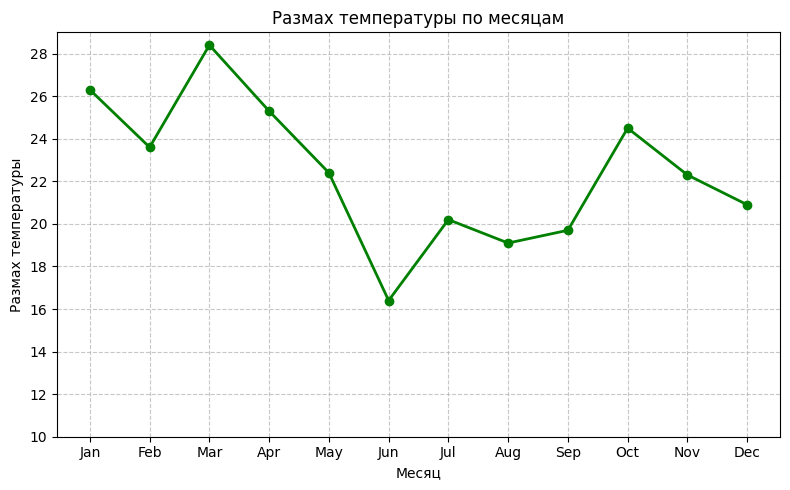

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(df_month['Month_Name'], df_month['Temperature'], marker='o', color='green', linewidth=2)
plt.title('Размах температуры по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Размах температуры')
plt.yticks(np.arange(10, 30, 2))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

In [25]:
stats_by_month = df.groupby('Month')['Temperature'].agg(['max', 'min', lambda x: x.max() - x.min()]).reset_index()
stats_by_month.columns = ['Month', 'Max_Temperature', 'Min_Temperature', 'Range']
stats_by_month

,Month,Max_Temperature,Min_Temperature,Range
0,1,8.5,-17.8,26.3
1,2,10.3,-13.3,23.6
2,3,21.8,-6.6,28.4
3,4,25.9,0.6,25.3
4,5,29.4,7.0,22.4
5,6,32.7,16.3,16.4
6,7,38.0,17.8,20.2
7,8,39.4,20.3,19.1
8,9,30.5,10.8,19.7
9,10,25.3,0.8,24.5


6. Найдите, сколько дней работа проката по оценкам была выше среднего. В этом случае
следует учитывать, что оценки выставлялись по разным шкалам, поэтому 10 по одной
шкале это отлично, а по другой очень плохо. Для решения этой проблемы используют так
называемую «z-стандартизацию», т. е. вводят новую переменную
z = (x - m) / σ,
которая показывает на сколько среднеквадратичных отклонений x  отклоняется от среднего.

In [26]:
stats = df.groupby('score_type')['score'].agg(['mean', 'std']).reset_index()

In [27]:
df = df.merge(stats, on='score_type') # Добавляем mean и std к каждой строке по своей шкале

In [28]:
df['z_score'] = (df['score'] - df['mean']) / df['std']

In [29]:
z_by_day = df.groupby(df['Date'].dt.date)['z_score'].mean().reset_index()
z_by_day.columns = ['Date', 'Mean_Z_Score']
z_by_day

,Date,Mean_Z_Score
0,2017-12-01,-0.207944
1,2017-12-02,-0.028922
2,2017-12-03,0.127262
3,2017-12-04,-0.063843
4,2017-12-05,-0.103157
...,...,...
360,2018-11-26,-0.077364
361,2018-11-27,-0.356769
362,2018-11-28,0.160309
363,2018-11-29,0.178753


In [30]:
days = z_by_day[z_by_day['Mean_Z_Score'] > 0]
count_days = len(days)
days, count_days

(           Date  Mean_Z_Score
 2    2017-12-03      0.127262
 5    2017-12-06      0.087854
 6    2017-12-07      0.142077
 7    2017-12-08      0.222302
 8    2017-12-09      0.325929
 ..          ...           ...
 355  2018-11-21      0.370500
 358  2018-11-24      0.060735
 362  2018-11-28      0.160309
 363  2018-11-29      0.178753
 364  2018-11-30      0.300498
 
 [182 rows x 2 columns],
 182)

7) Установить наличие линейной зависимости между температурой и числом
арендованных велосипедов (по данным за весь год, по сезонам, по месяцам). Для данных,
имеющих максимальную линейную зависимость, построить график рассеяния.

In [36]:
seasons_corr = df.groupby('Seasons')[['Temperature', 'Rental count']].corr().iloc[0::2, 1]
seasons_corr = seasons_corr.reset_index()
seasons_corr = seasons_corr[['Seasons', 'Rental count']]
seasons_corr.columns = ['Сезон', 'Корреляция']

display(seasons_corr)

max_corr_season = seasons_corr.loc[seasons_corr['Корреляция'].abs().idxmax()]
print(f"Максимальная корреляция: {max_corr_season['Сезон']} = {max_corr_season['Корреляция']:.3f}")


,Сезон,Корреляция
0,Autumn,0.263716
1,Spring,0.473204
2,Summer,0.131788
3,Winter,0.305433


Максимальная корреляция: Spring = 0.473


In [44]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

df['Year'] = df['Date'].dt.year

df

,Unnamed: 0,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,...,score,score_type,Temperature Category,Month,mean,std,z_score,Year,Day,Weekday
0,0,2017-12-01,0,-5.2,37,2.2,0.0,0.0,Winter,No Holiday,...,56.0,0-100,frost,12,44.552083,32.218213,0.355324,2017,1,Friday
1,1,2017-12-01,1,-5.5,38,0.8,0.0,0.0,Winter,No Holiday,...,3.0,0-10,frost,12,6.788667,2.571681,-1.473226,2017,1,Friday
2,2,2017-12-01,2,-6.0,39,1.0,0.0,0.0,Winter,No Holiday,...,7.0,0-10,frost,12,6.788667,2.571681,0.082177,2017,1,Friday
3,3,2017-12-01,3,-6.2,40,0.9,0.0,0.0,Winter,No Holiday,...,8.0,0-10,frost,12,6.788667,2.571681,0.471028,2017,1,Friday
4,4,2017-12-01,4,-6.0,36,2.3,0.0,0.0,Winter,No Holiday,...,10.0,0-100,frost,12,44.552083,32.218213,-1.072439,2017,1,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,8755,2018-11-30,19,4.2,34,2.6,0.0,0.0,Autumn,No Holiday,...,55.0,0-100,cold,11,44.552083,32.218213,0.324286,2018,30,Friday
8756,8756,2018-11-30,20,3.4,37,2.3,0.0,0.0,Autumn,No Holiday,...,10.0,0-100,cold,11,44.552083,32.218213,-1.072439,2018,30,Friday
8757,8757,2018-11-30,21,2.6,39,0.3,0.0,0.0,Autumn,No Holiday,...,8.0,0-10,cold,11,6.788667,2.571681,0.471028,2018,30,Friday
8758,8758,2018-11-30,22,2.1,41,1.0,0.0,0.0,Autumn,No Holiday,...,8.0,0-10,cold,11,6.788667,2.571681,0.471028,2018,30,Friday


In [45]:
month_corr = df.groupby('Month')[['Temperature', 'Rental count']].corr().iloc[0::2, 1]
month_corr = month_corr.reset_index()
month_corr = month_corr[['Month', 'Rental count']]
month_corr.columns = ['Месяц', 'Корреляция']

display(month_corr)

max_corr_month = month_corr.loc[month_corr['Корреляция'].abs().idxmax()]
print(f"Максимальная корреляция: {max_corr_month['Месяц']} = {max_corr_month['Корреляция']:.3f}")


,Месяц,Корреляция
0,1,0.305854
1,2,0.409188
2,3,0.436654
3,4,0.513314
4,5,0.392751
5,6,0.385684
6,7,0.250374
7,8,0.166748
8,9,0.423088
9,10,0.212435


Максимальная корреляция: 4.0 = 0.513


In [41]:
year_corr = df.groupby('Year')[['Temperature', 'Rental count']].corr().iloc[0::2, 1]
year_corr = year_corr.reset_index()
year_corr = year_corr[['Year', 'Rental count']]
year_corr.columns = ['Год', 'Корреляция']

display(year_corr)

max_corr_year = year_corr.loc[year_corr['Корреляция'].abs().idxmax()]
print(f"Максимальная корреляция: {max_corr_year['Год']} = {max_corr_year['Корреляция']:.3f}")

,Год,Корреляция
0,2017,0.178960
1,2018,0.427203


Максимальная корреляция: 2018.0 = 0.427


In [48]:
corr = pd.DataFrame({
    'Показатели': ['Сезон', 'Месяц', 'Год'],
    'Значения': [max_corr_season['Сезон'], max_corr_month['Месяц'], max_corr_year['Год']],
    'Корреляция': [max_corr_season['Корреляция'], max_corr_month['Корреляция'], max_corr_year['Корреляция']]
})

corr

,Показатели,Значения,Корреляция
0,Сезон,Spring,0.473204
1,Месяц,4.0,0.513314
2,Год,2018.0,0.427203


In [49]:
max_corr = corr.loc[corr['Корреляция'].abs().idxmax()]
max_corr

Показатели       Месяц
Значения           4.0
Корреляция    0.513314
Name: 1, dtype: object

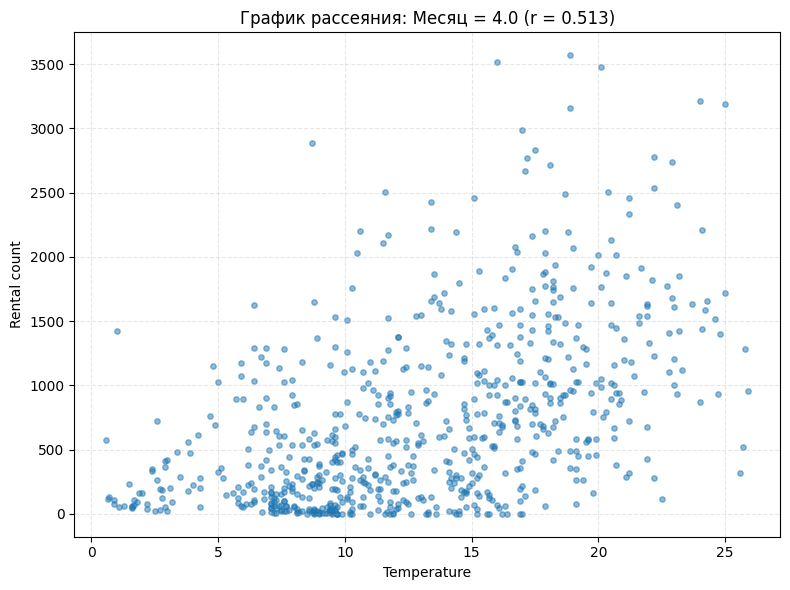

In [59]:
# Подмножество с максимальной по модулю корреляцией и scatter-график
metric = max_corr['Показатели']
val = max_corr['Значения']

if metric == 'Месяц':
	best_data = df[df['Month'] == int(val)]
elif metric == 'Сезон':
	best_data = df[df['Seasons'] == val]
elif metric == 'Год':
	best_data = df[df['Year'] == int(val)]
else:
	best_data = df.copy()

r = best_data['Temperature'].corr(best_data['Rental count'])

plt.figure(figsize=(8, 6))
plt.scatter(best_data['Temperature'], best_data['Rental count'], alpha=0.5, s=15)
plt.title(f"График рассеяния: {metric} = {val} (r = {r:.3f})")
plt.xlabel('Temperature')
plt.ylabel('Rental count')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

8. Аналогичные п.7 исследования провести для температуры и оценки.

In [63]:
seasons_corr_score = df.groupby('Seasons')[['Temperature', 'score']].corr().iloc[0::2, 1]
seasons_corr_score = seasons_corr_score.reset_index()
seasons_corr_score = seasons_corr_score[['Seasons', 'score']]
seasons_corr_score.columns = ['Сезон', 'Корреляция']

display(seasons_corr_score)

max_corr_season_score = seasons_corr_score.loc[seasons_corr_score['Корреляция'].abs().idxmax()]
print(f"Максимальная корреляция: {max_corr_season_score['Сезон']} = {max_corr_season_score['Корреляция']:.3f}")

,Сезон,Корреляция
0,Autumn,-0.015442
1,Spring,0.013424
2,Summer,0.017308
3,Winter,-0.060134


Максимальная корреляция: Winter = -0.060


In [64]:
month_corr_score = df.groupby('Month')[['Temperature', 'score']].corr().iloc[0::2, 1]
month_corr_score = month_corr_score.reset_index()
month_corr_score = month_corr_score[['Month', 'score']]
month_corr_score.columns = ['Месяц', 'Корреляция']

display(month_corr_score)

max_corr_month_score = month_corr_score.loc[month_corr_score['Корреляция'].abs().idxmax()]
print(f"Максимальная корреляция: {max_corr_month_score['Месяц']} = {max_corr_month_score['Корреляция']:.3f}")


,Месяц,Корреляция
0,1,-0.068602
1,2,-0.076715
2,3,-0.038723
3,4,-0.009944
4,5,0.081658
5,6,-0.009443
6,7,-0.030638
7,8,0.050050
8,9,0.016821
9,10,-0.003089


Максимальная корреляция: 5.0 = 0.082


In [65]:
year_corr_score = df.groupby('Year')[['Temperature', 'score']].corr().iloc[0::2, 1]
year_corr_score = year_corr_score.reset_index()
year_corr_score = year_corr_score[['Year', 'score']]
year_corr_score.columns = ['Год', 'Корреляция']

display(year_corr_score)

max_corr_year_score = year_corr_score.loc[year_corr_score['Корреляция'].abs().idxmax()]
print(f"Максимальная корреляция: {max_corr_year_score['Год']} = {max_corr_year_score['Корреляция']:.3f}")


,Год,Корреляция
0,2017,-0.021417
1,2018,-0.012264


Максимальная корреляция: 2017.0 = -0.021


In [67]:
corr_score = pd.DataFrame({
    'Показатели': ['Сезон', 'Месяц', 'Год'],
    'Значения': [max_corr_season_score['Сезон'], max_corr_month_score['Месяц'], max_corr_year_score['Год']],
    'Корреляция': [max_corr_season_score['Корреляция'], max_corr_month_score['Корреляция'], max_corr_year_score['Корреляция']]
})

corr_score

,Показатели,Значения,Корреляция
0,Сезон,Winter,-0.060134
1,Месяц,5.0,0.081658
2,Год,2017.0,-0.021417


In [68]:
max_corr_score = corr_score.loc[corr_score['Корреляция'].abs().idxmax()]
max_corr_score

Показатели       Месяц
Значения           5.0
Корреляция    0.081658
Name: 1, dtype: object

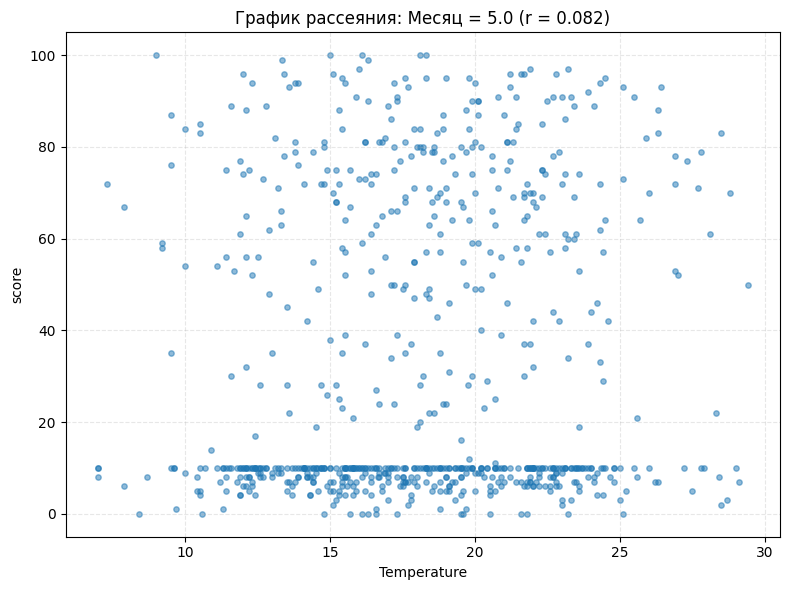

In [69]:
# Подмножество с максимальной по модулю корреляцией и scatter-график
metric = max_corr_score['Показатели']
val = max_corr_score['Значения']

if metric == 'Месяц':
	best_data_score = df[df['Month'] == int(val)]
elif metric == 'Сезон':
	best_data_score = df[df['Seasons'] == val]
elif metric == 'Год':
	best_data_score = df[df['Year'] == int(val)]
else:
	best_data_score = df.copy()

r = best_data_score['Temperature'].corr(best_data_score['score'])

plt.figure(figsize=(8, 6))
plt.scatter(best_data_score['Temperature'], best_data_score['score'], alpha=0.5, s=15)
plt.title(f"График рассеяния: {metric} = {val} (r = {r:.3f})")
plt.xlabel('Temperature')
plt.ylabel('score')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()